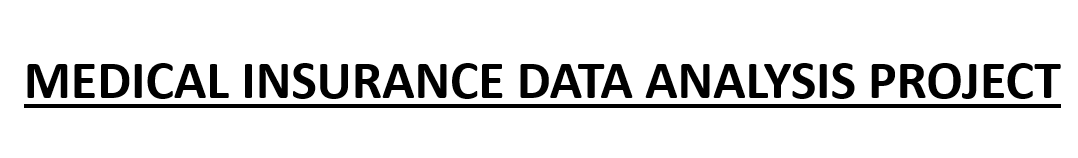
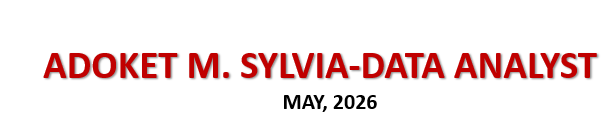

This project demonstrates how data science is used in healthcare to analyze medical insurance data and understand the factors that influence healthcare costs.The analysis focuses on identifying relationships between demographic characteristics, lifestyle habits, and insurance charges to generate meaningful insights for healthcare decision-making and predictive modeling.

**Project Objectives**
- Data Preparation: Clean and preprocess healthcare insurance data for analysis
- Pattern Exploration: Explore patterns and trends in medical insurance charges
- Demographic Analysis: Investigate how demographic factors such as age and gender influence healthcare expenses
- Lifestyle Impact: Examine the impact of lifestyle factors such as: Smoking habits, Body Mass Index (BMI)on insurance costs
- Family Variables: Analyze family-related variables such as the number of dependents covered by insurance
- Geographic Comparison: Compare insurance charges across different geographic regions

## 1. **Data Collection and Loading**

#### (a.) **Loading Libraries**

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


#### (b.) **Importing Data Set**

In [12]:
df = pd.read_csv("insurance_data.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## **Dataset Overview**

**Total Records:** 1,338 rows.

**Target Variable:** charges (the medical insurance cost we want to explain and predict).

**Predictor Variables:** 6 features total.
###### Numerical: age, bmi, children.
###### Categorical: sex, smoker, region.

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [15]:
df.shape

(1338, 7)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [17]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. **Data Cleaning and Preprocessing**

#### (a.) **Checking for missing values**

In [19]:
miss_values=df.isnull().sum()
miss_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### (b.) **Checking and Removing Duplicates**

In [20]:
df.duplicated().sum()

np.int64(1)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

#### (c.) **Exploring Region Distribution**

In [23]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

#### (d.) **Encode Categorical Variables**

In [24]:
df['sex']=pd.Categorical(df['sex'])
df['smoker']=pd.Categorical(df['smoker'])
df['region']=pd.Categorical(df['region'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.6 KB


#### (e.) **Checking for Outliers (Using Body Mass Index and Charges)**

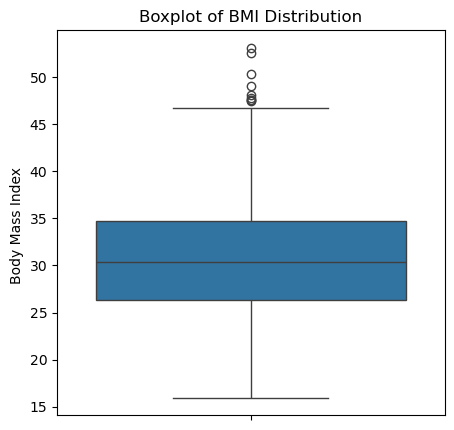

In [26]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df, y="bmi")
plt.title("Boxplot of BMI Distribution")
plt.ylabel("Body Mass Index ")
plt.show()

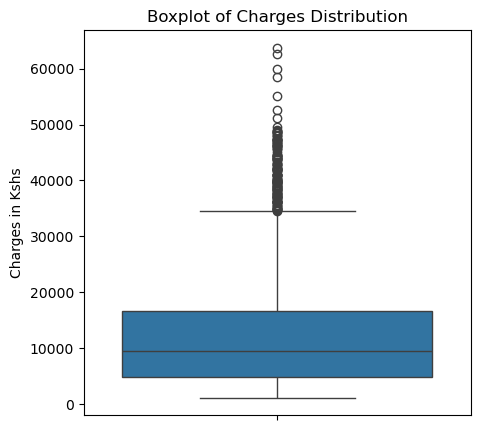

In [27]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

#### (f.) **Removing Outliers**

##### (a.) **Body Mass Index (BMI)**

In [28]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df1 = df[(df["bmi"] >= lower_bound) & (df["bmi"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


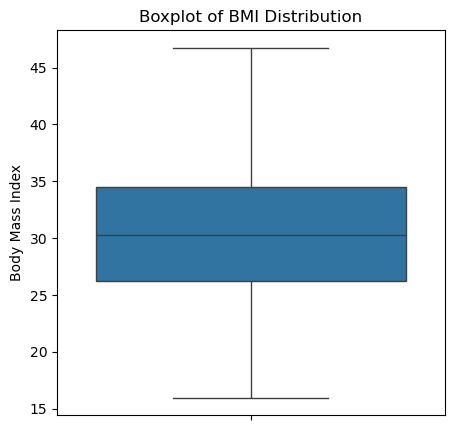

In [29]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df1, y="bmi")
plt.title("Boxplot of BMI Distribution")
plt.ylabel("Body Mass Index")
plt.show()

##### (b.) **Charges**

In [30]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df1 = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


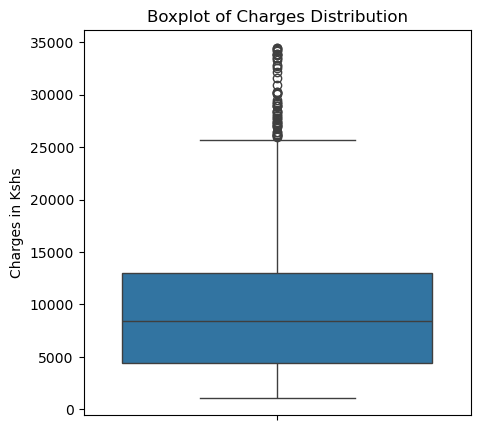

In [31]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df1, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

In [32]:
Q1 = df1["charges"].quantile(0.25)
Q3 = df1["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df2 = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


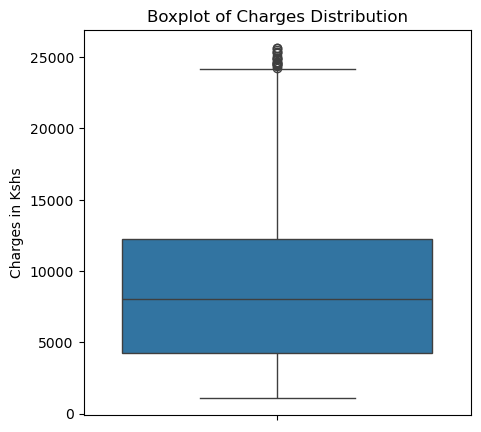

In [33]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df2, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

In [34]:
Q1 = df2["charges"].quantile(0.25)
Q3 = df2["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df3 = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


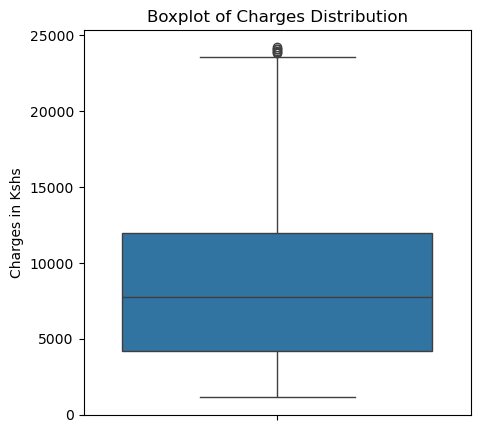

In [35]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df3, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

In [36]:
Q1 = df3["charges"].quantile(0.25)
Q3 = df3["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df4 = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


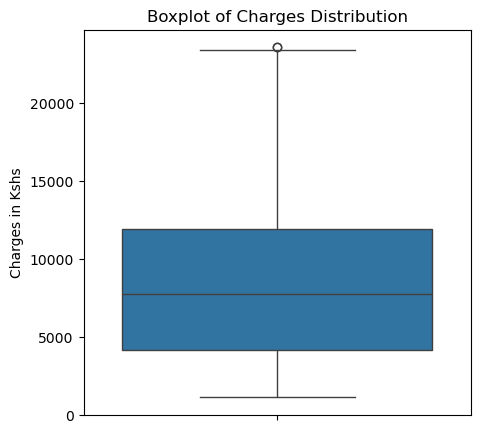

In [37]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df4, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

In [38]:
Q1 = df4["charges"].quantile(0.25)
Q3 = df4["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df5 = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]
print("outlier removed successfully")

outlier removed successfully


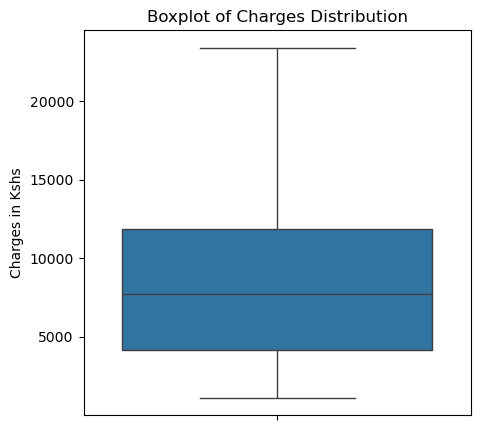

In [39]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df5, y="charges")
plt.title("Boxplot of Charges Distribution")
plt.ylabel("Charges in Kshs")
plt.show()

In [40]:
summary_statistics=df5.describe()
summary_statistics

,age,bmi,children,charges
count,1115.000000,1115.000000,1115.000000,1115.000000
mean,38.483408,30.159161,1.078924,8590.254464
std,13.864646,6.101248,1.217414,5420.674719
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,25.800000,0.000000,4150.382350
50%,38.000000,29.810000,1.000000,7729.645750
75%,50.000000,33.990000,2.000000,11880.231025
max,64.000000,53.130000,5.000000,23401.305750


## 3. **Data Visualization**

### (a.) **By Histogram**
#### Histogram of Charges

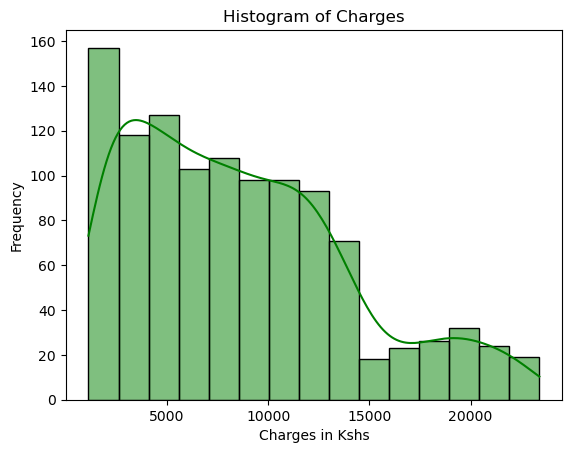

In [52]:
import seaborn as sns
plt.figure()
sns.histplot(df5,x='charges',bins=15,color='green',kde=True)
plt.title('Histogram of Charges')
plt.xlabel('Charges in Kshs')
plt.ylabel('Frequency')
plt.show()


The histogram shows that the medical insurance charges variable is heavily right-skewed, meaning the data is not normally distributed. Most of the values are clustered below 5,000, indicating that the majority of individuals in the sample have relatively low healthcare expenses.

As the charges increase, the number of individuals decreases, but the distribution stretches far toward higher values. There is also a smaller peak between 15,000 and 25,000, suggesting that while fewer people experience high medical costs, they still represent a meaningful portion of the dataset.

This pattern is quite different from the more balanced and symmetrical distribution seen in BMI. The presence of these high-cost outliers means that the mean insurance charge may be pulled upward, making it less representative of the typical individual. As a result, other measures such as the median may provide a better summary of the central tendency for this variable.

#### Histogram of BMI

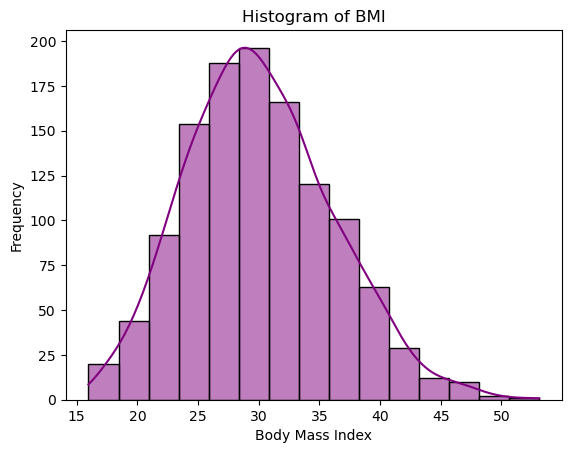

In [50]:

plt.figure()
sns.histplot(df1,x='bmi',bins=15,color='purple',kde=True)
plt.title('Histogram of BMI')
plt.xlabel('Body Mass Index')
plt.ylabel('Frequency')
plt.show()


### Interpretation of the BMI Histogram

The histogram shows that the **Body Mass Index (BMI)** variable has a fairly symmetrical and approximately normal (bell-shaped) distribution. Most of the BMI values are concentrated between **28 and 31**, suggesting that a large proportion of the individuals in the sample fall within the **overweight or obese** categories.

Very low BMI values (below **18.5**, which indicate underweight) and extremely high BMI values (above **45**, which indicate severe obesity) appear much less frequently, showing that such cases are uncommon in the dataset.

Unlike the distribution of insurance charges, which is often highly skewed, the BMI values are more evenly spread around the center. This suggests that while body mass is relatively balanced across the population, its effect on healthcare costs may vary significantly and may not follow the same pattern as BMI itself.


### (b.) **Scatter Plot**

#### Charges on Age by Sex

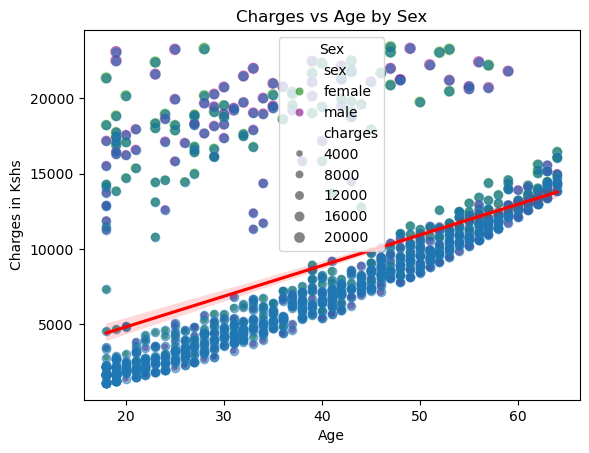

In [43]:
sns.scatterplot(data=df5, x='age', y='charges', hue='sex', size='charges', alpha=0.6, palette=['green', 'purple'])
sns.regplot(x='age', y='charges', data=df5, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})
plt.title("Charges vs Age by Sex")
plt.xlabel("Age")
plt.ylabel("Charges in Kshs")
plt.legend(title='Sex')
plt.show()


The scatter plot shows a positive linear relationship between age and medical insurance charges, meaning that insurance costs generally increase as a person gets older. The upward trend from left to right suggests that age plays an important role in determining baseline healthcare expenses.

However, the plot also reveals two noticeable parallel groups of data points positioned above the main cluster. This pattern suggests that there are other factors, beyond age, that strongly influence insurance charges and cause certain individuals to experience significantly higher costs.

Additionally, the green and purple data points (representing different sexes) are spread across all charge levels without any clear separation. This indicates that sex does not appear to be a major factor in explaining the differences in insurance costs.

Overall, the scatter plot suggests that while age contributes to a steady increase in insurance charges, it cannot fully explain the larger variations in cost. Other variables are likely responsible for the sudden increases in charges and should be considered alongside age for a more complete understanding.

#### Charges on Body Mass Index by Smoker

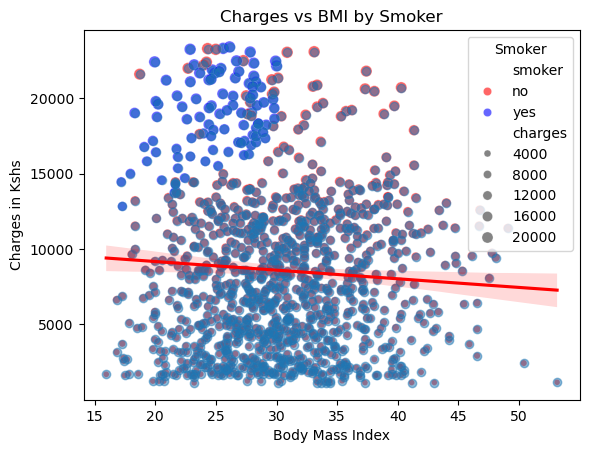

In [44]:
sns.scatterplot(data=df5, x='bmi', y='charges', hue='smoker', size='charges', alpha=0.6, palette=['red', 'blue'])
sns.regplot(x='bmi', y='charges', data=df5, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})
plt.title("Charges vs BMI by Smoker")
plt.xlabel("Body Mass Index")
plt.ylabel("Charges in Kshs")
plt.legend(title='Smoker')
plt.show()

The scatter plot shows that medical insurance charges do not have a simple or consistent relationship with Body Mass Index (BMI) when the entire population is considered. The overall regression line appears relatively flat, suggesting that BMI alone does not strongly or steadily increase healthcare costs.

However, a clear distinction emerges when smoking status is taken into account. Individuals who smoke (represented by blue markers) are concentrated in the higher-cost range, showing significantly greater insurance charges across nearly all BMI levels. On the other hand, non-smokers (represented by red markers) remain mostly clustered in the lower-cost range, even as BMI increases.

This separation indicates that smoking status is a major factor influencing medical insurance charges, with a much stronger impact than BMI alone. While BMI may contribute to health risk, smoking appears to dramatically increase financial risk, pushing individuals into a substantially higher insurance cost category.

## (c.) **Box Plots**

#### Smoker Status Impact on Charges

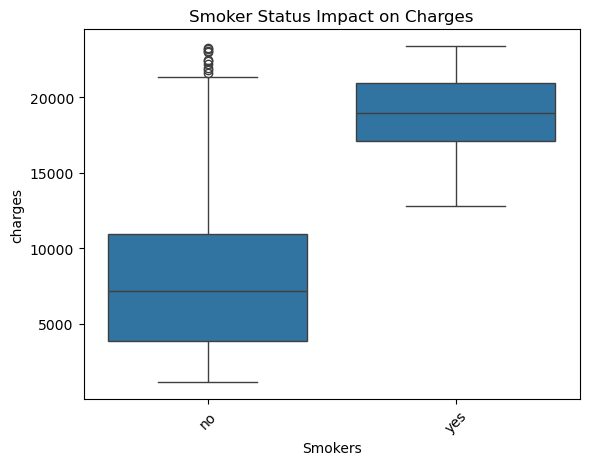

In [45]:
sns.boxplot(x='smoker', y='charges', data=df5)
plt.xlabel('Smokers')
plt.title('Smoker Status Impact on Charges')
plt.xticks(rotation=45)
plt.show()


The box plot shows that medical insurance charges vary significantly depending on smoking status. For non-smokers, the median insurance charge is much lower, centered around 7,000, and most of their charges fall below 11,000. Although there are a few high-cost outliers reaching above 21,000, the majority of non-smokers remain within a relatively lower cost range.

In contrast, the smoker group has a much higher median charge, close to 19,000, indicating substantially greater healthcare expenses. Their entire interquartile range lies above the upper quartile of the non-smoker group, meaning that even the typical lower charges among smokers exceed most of the charges observed for non-smokers.

The clear separation between the two groups suggests that smoking has a major impact on insurance costs. It acts as a strong risk factor that significantly increases medical charges, creating a distinct financial divide between lower-risk non-smokers and higher-cost smokers.

#### Region Variation on Charges

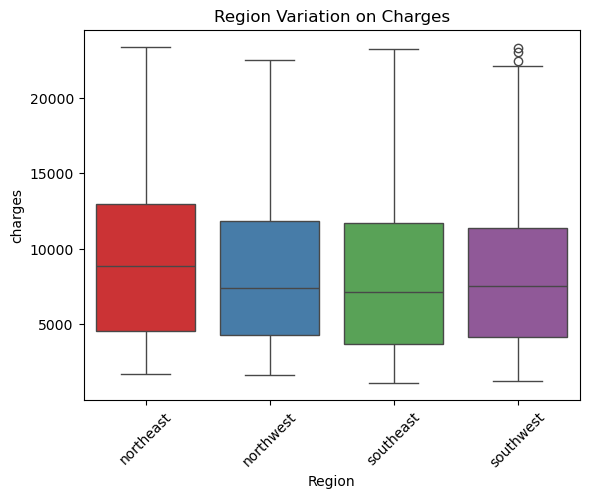

In [49]:
sns.boxplot(x='region', y='charges', data=df5, palette=('Set1'))
plt.xlabel('Region')
plt.title('Region Variation on Charges')
plt.xticks(rotation=45)
plt.show()
import warnings
warnings.filterwarnings('ignore')

The box plot shows that medical insurance charges are relatively consistent across the different geographical regions. The median charges for all four regions fall within a similar range, approximately between 7,000 and 9,000, suggesting that location alone does not lead to major differences in baseline healthcare costs.

Although the northeast region appears to have a slightly higher median and a somewhat wider upper distribution, the overall spread of the data, including the interquartile ranges and maximum values, remains quite similar across all regions.

This similarity indicates that geographical region is likely a less important factor in determining insurance charges. Compared to variables such as health conditions or lifestyle choices, location seems to have only a limited influence on the overall cost of medical insurance.

#### Sex Differences on Charges

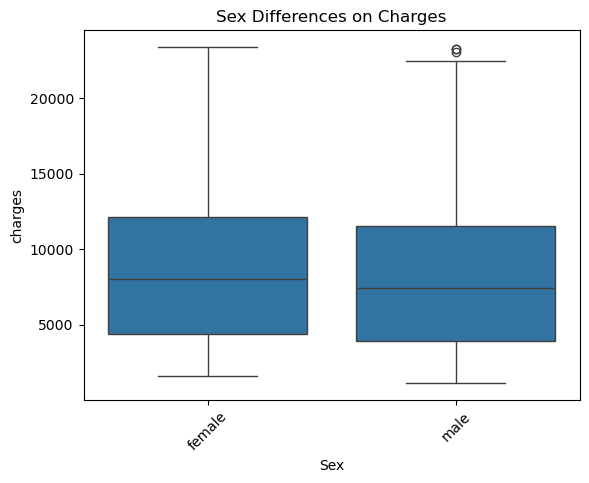

In [47]:

sns.boxplot(x='sex', y='charges', data=df5)
plt.xlabel('Sex')
plt.title('Sex Differences on Charges')
plt.xticks(rotation=45)
plt.show()


The box plot shows that medical insurance charges are very similar between male and female individuals. The median cost for both groups falls close to 7,500 to 8,000, indicating that the typical healthcare expenses are nearly the same regardless of sex.

The interquartile ranges, which represent the middle 50% of the data, are also almost identical in both spread and position. This suggests that the overall distribution of insurance charges is highly consistent between males and females.

Although the male group appears to have a few slightly higher outliers, the main distributions for both groups overlap almost completely. This strong similarity implies that sex is not a major independent factor in determining medical insurance premiums. Instead, other variables such as lifestyle habits and health-related characteristics are likely to play a much more significant role in predicting insurance costs.

## (d.) **Count Plot**

#### Smoking Status by Sex

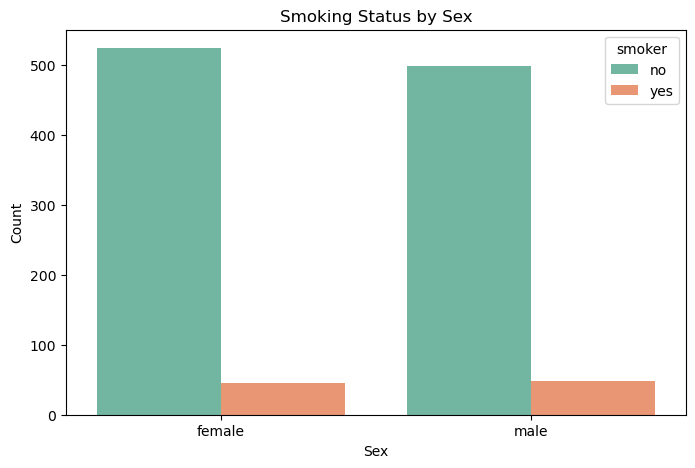

In [48]:
plt.figure(figsize=(8,5))
sns.countplot(df5, x='sex',  hue='smoker', palette='Set2')
plt.title('Smoking Status by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

The count plot shows that non-smokers make up the majority of the population for both males and females. In each sex category, the number of individuals classified as non-smokers is significantly higher, with counts close to or above 500.

In comparison, the number of individuals who smoke is much lower, with fewer than 100 smokers in both the male and female groups. This indicates that smoking is relatively uncommon within the dataset.

The similar distribution of smoking status across both sexes suggests that smoking prevalence is fairly balanced between males and females. This balanced representation strengthens the reliability of any later analysis involving smoking, as differences in insurance costs related to smoking are less likely to be influenced by unequal sample sizes between genders.

## (e.) **Heatmap(Correlation Matrix)**

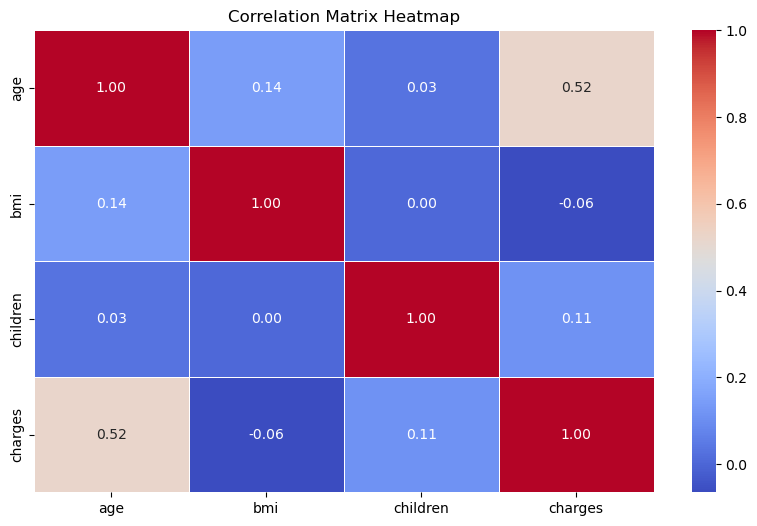

In [41]:
plt.figure(figsize=(10, 6))
corr_matrix = df5.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

The correlation matrix heatmap shows the strength and direction of the relationships between the numerical variables in the dataset. Among all variables, age has the strongest positive correlation with medical insurance charges, with a coefficient of 0.52. This suggests that as age increases, insurance costs also tend to rise, making age an important predictor of healthcare expenses.

The variable children has only a very weak positive correlation with charges (0.11), indicating that the number of dependents has little direct influence on insurance costs. Surprisingly, body mass index (BMI) shows an almost negligible correlation with charges, suggesting that BMI alone does not have a strong linear effect on medical expenses when considered across the entire population.

The relationships among the predictor variables themselves, such as the weak correlation between age and BMI, are also very low. This indicates that multicollinearity is not a major issue, meaning the variables are largely independent of one another and can be used together effectively in predictive modeling.

# 4. **Hypothesis Testing**

In [42]:
import pingouin as pg

### 1. **One Sample t-test ( by Age)**

H0: Sample mean of age is not significantly different from population mean

H1: Sample mean of age is significantly different from population mean


In [43]:

age = df5 ['age'] 
test_value = 30
one_sample_t_test = pg.ttest(age, test_value)
one_sample_t_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,20.431442,1114,two-sided,4.713862e-79,"[37.67, 39.3]",0.611873,1.0,2.197e+75


The one-sample t-test results show that the p-value is below the 0.05 significance level, meaning the null hypothesis is rejected. This indicates that the sample mean age is significantly different from the population mean used for comparison.

The 95% confidence interval, ranging from 37.67 to 39.30 years, suggests that the true average age of the population is likely to fall within this range. This implies that the individuals in the sample tend to be somewhat older than the baseline population mean.

In addition, the Cohen’s d value of 0.61 indicates a moderate effect size, meaning that the difference between the sample mean and the population mean is not only statistically significant but also practically meaningful. Overall, these results suggest that age is an important characteristic in describing the population represented in the dataset.

### 2. **Two Sample t-test**
#### (a.) **On Sex and Charges**

 H0: There is no significance difference on the charges between male and female

 H1: There is significance difference on the charges between male and female


In [44]:

group_A = df5[df5['sex'] == 'male']['charges'].dropna()
group_B = df5[df5['sex'] == 'female']['charges'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-1.077947,1102.455009,two-sided,0.281293,"[-988.32, 287.44]",0.064653,0.190163,0.119


The two-sample t-test results show that the p-value is approximately 0.28, which is higher than the 0.05 significance level. This means that the null hypothesis cannot be rejected, indicating that there is no statistically significant difference in medical insurance charges between male and female individuals.

The 95% confidence interval, which ranges from -988.32 to 287.44, includes zero. This further confirms that the observed difference between the average charges of the two groups is likely due to random variation rather than a true difference.

Additionally, the Cohen’s d value of 0.06 suggests a negligible effect size, meaning the difference between males and females is not only statistically insignificant but also practically unimportant. Overall, these results indicate that biological sex does not appear to be a meaningful factor in determining medical insurance costs within this population.

#### (b.) **On Smoker and Age**

H0: There is no significant difference in age between smokers and non-smokers

H1: There is significant difference in age between smokers and non-smokers

In [45]:

group_A = df5[df5['smoker'] == 'yes']['age'].dropna()
group_B = df5[df5['smoker'] == 'no']['age'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-5.846699,126.305201,two-sided,4.027670e-08,"[-8.93, -4.42]",0.485514,0.994112,1.423e+06


Since p_value is < 0.05, we reject null hypothesis and conclude that there is significant difference in age between smokers and non-smokers

#### (c.) **On Smoker and Charges**

H0: There is no significant difference in charges between smokers and non-smokers

H1: There is significant difference in charges between smokers and non-smokers

In [46]:

group_A = df5[df5['smoker'] == 'yes']['charges'].dropna()
group_B = df5[df5['smoker'] == 'no']['charges'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,37.51625,155.333713,two-sided,9.041939e-80,"[10566.96, 11741.57]",2.501613,1.0,1.922e+195


Since p_value is < 0.05, we reject null hypothesis and conclude that there is significant difference in charges between smokers and non-smokers

# 5. **Chi-Square Test**
#### (a.) **Chi-Square test on sex and smoker**

H0: There is no association between sex and smoker (they are independent of each other)

H1: There is an association between sex and smoker (they are dependent of each other)

In [47]:
import scipy.stats as stats


In [48]:
contingency_table = pd.crosstab(df5["sex"], df5["smoker"])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result (sex vs smoker):")
print("Chi2:", chi2, "p-value:", p, "Degrees of Freedom:", dof)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Test Result (sex vs smoker):
Chi2: 0.18019395271506353 p-value: 0.6712066136177612 Degrees of Freedom: 1
p-value: 0.6712066136177612
Degrees of Freedom: 1


The chi-square test of independence shows that there is no statistically significant relationship between biological sex and smoking status. Since the p-value is approximately 0.67, which is much higher than the standard significance level of 0.05, the null hypothesis cannot be rejected. This means that any differences observed in smoking behavior between males and females are likely due to random chance rather than a real association.

The chi-square statistic of 0.18, with 1 degree of freedom, further supports this conclusion because it indicates only a very small difference between the observed and expected smoking patterns. In other words, the distribution of smokers and non-smokers appears to be similar across both genders.

Overall, the findings suggest that smoking habits are fairly evenly distributed between males and females in the dataset, with no evidence that one gender is more likely to smoke than the other.

#### (b.) **Chi-Square Test on age and smoker**

H0: There is no association between age and smoker (they are independent of each other)

H1: There is an association between age and smoker (they are dependent of each other)

In [51]:
contingency_table = pd.crosstab(df5["age"], df5["smoker"])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result (age vs smoker):")
print("Chi2:", chi2, "p-value:", p, "Degrees of Freedom:", dof)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Test Result (age vs smoker):
Chi2: 74.76390446151368 p-value: 0.004651898797871392 Degrees of Freedom: 46
p-value: 0.004651898797871392
Degrees of Freedom: 46


Since 0.0046 < 0.05, we reject the null hypothesis and conclude that there is a statistically significant relationship between age and smoking status.

# 6. **Regression Analysis**

#### **Multiple Linear Regression Model**

In [50]:
import statsmodels.api as sm
x=df5[["age","bmi","children"]]
y=df5["charges"]
# Fill missing values with column mean
x = x.fillna(x.mean())
x = sm.add_constant(x)
# Run regression
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     157.8
Date:                Wed, 20 May 2026   Prob (F-statistic):           3.33e-85
Time:                        15:09:16   Log-Likelihood:                -10970.
No. Observations:                1115   AIC:                         2.195e+04
Df Residuals:                    1111   BIC:                         2.197e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3859.1278    751.286      5.137      0.0

## **Model Fit**

**R-squared (0.299):**
The model explains 29.9% of the variance in charges.

**F-statistic (157.8):**
The overall model is highly statistically significant (p < 0.001).

**Observations (1115):** 
The dataset has a robust sample size.

## **Coefficients & Interpretation**
All predictors are statistically significant (p = 0.000).

**Intercept (const = 3859.13):**
Baseline charges when all predictors are zero.

**Age (209.94):**
Each additional year increases charges by 209.94 units.

**BMI (-125.98):** 
Each unit increase in BMI decreases charges by 125.98 units.

**Children (418.08):**
Each additional child increases charges by 418.08 units.


## **Diagnostic Tests**

**Durbin-Watson (1.917):**
No significant autocorrelation in the errors.

**Jarque-Bera (p < 0.001):**
Residuals are not normally distributed.

**Skew (2.032):**
Residuals are highly right-skewed.

**Condition Number (278):**
Multicollinearity is within acceptable limits.

## 7. **Interpretation and Insights**

**Cost Determinants:** Smoking status represents the absolute strongest catalyst for premium escalation, completely overwhelming standard demographic identifiers. Advancing age operates as a steady, continuous driver of healthcare costs, compounding baseline financial risk by approximately $210 annually. Body mass index behaves non-ly, acting as a moderate baseline indicator that can scale into extreme cost outliers when interacting with behavioral variables like smoking.

**Risk Profiles:** The highest risk subpopulation is explicitly defined by tobacco users who possess an elevated body mass index, forming a specific high-cost cluster that forces the population mean upward and accounts for disproportionately large total payouts. Conversely, biological sex and regional territories present static, uniform cost distributions with overlapping medians, establishing that demographic and geographic features are minor predictors of final risk.

**Actionable Business Recommendations:** Insurance institutions should structurally decouple premium frameworks from geographic or gender indicators, prioritizing penalty adjustments almost entirely around active smoking status and high-risk body mass configurations. Concurrently, healthcare policy-makers and insurers can maximize financial returns by directing preventative funding toward targeted smoking cessation programs and chronic metabolic health initiatives, directly treating the primary user brackets responsible for the most severe healthcare claims.






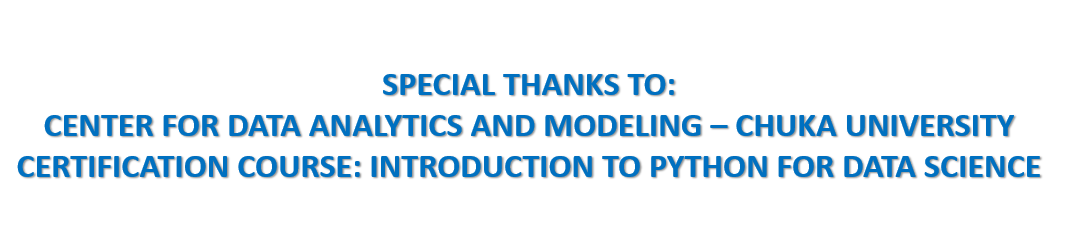